<a href="https://colab.research.google.com/github/CaioAntonine/CaioAntonine_MVP_CEP/blob/main/MVP_CEP_2026/01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — CEP: Controle de Qualidade na Produção de Café Especial

**Universidade de Brasília — Departamento de Engenharia de Produção** **Disciplina:** Controle Estatístico de Processos
**Aluno:** Caio Antonine Pereira Gomes — 231013313  
**Professor:** Andre Luiz Marques Serrano  

---

## Resumo

Este notebook apresenta o desenvolvimento de um MVP para classificação supervisionada no processo de produção de café. O objetivo é prever, a partir de características físicas e de cultivo da fazenda, se um lote de café cru atingirá o grau de **Café Super Premium (+1)** ou se será classificado como **Café Premium (0)**, eliminando a dependência inicial de provas de degustação demoradas e permitindo um melhor planejamento de precificação.

O dataset utilizado é o **CQI (Coffee Quality Institute) Database**, focado em grãos Arábica.

---
# 1. Definição do Problema

## 1.1 Contexto
Na agroindústria do café, o valor de mercado de um lote é definido por avaliadores certificados (Q-Graders). Lotes que atingem pontuações elevadas (Cafés Especiais/Premium) são vendidos com margens de lucro imensamente superiores. No entanto, o processo de degustação é gargalo na cadeia produtiva.

## 1.2 Objetivo
Construir um modelo de **classificação binária** capaz de prever se um café será avaliado como Premium (Total.Cup.Points >= 82.5) baseado estritamente em **parâmetros de produção** (Altitude, Umidade, Quantidade de Defeitos do Grão e Método de Processamento).

## 1.3 Pergunta Central
> É possível prever se um lote de café possui qualidade Premium avaliando apenas as variáveis físicas e ambientais do seu processo de cultivo e colheita, sem utilizar as notas de degustação?

## 1.4 Premissas e Hipóteses
**Premissa 1:** Variáveis sensoriais (Aroma, Sabor) foram excluídas da modelagem, pois representam o resultado do processo, não as variáveis de controle da produção.

**Hipótese 1:** A altitude da fazenda e a quantidade primária de defeitos no grão (Category One Defects) são os maiores preditores físicos de um café de alta pontuação.

# 2. Informações sobre os dados
### 2.1 O que é o "Total Cup Points"?
É a métrica global de qualidade definida pela *Specialty Coffee Association* (SCA). Ela é o resultado de uma avaliação sensorial feita por especialistas (Q-Graders), que atribuem notas de 0 a 10 a atributos como: Aroma, Sabor, Acidez, Corpo, Equilíbrio e Doçura. A soma destes pontos gera o **Total Cup Points**.

### 2.2 Por que usamos o limite de 85 em vez de 80?
Internacionalmente, um café com nota **80** já é considerado "Especial" (Specialty). No entanto, este dataset específico contém lotes que já passaram por uma pré-seleção de alta qualidade. Se usássemos 80 como corte, teríamos **98%** da base como "Especial", o que tornaria o modelo de machine learning inútil (ele apenas "chutaria" que tudo é especial e acertaria quase sempre).

Ao subir a régua para **85**, focamos nos **Microlotes Super Premium** (a elite da produção, cerca de 23% da base). Isso cria um desafio real para o algoritmo identificar o que diferencia um café "bom" de um café "excecional".

### 2.3 Variáveis de Produção (Features)
Para evitar o **vazamento de dados** (usar a resposta para prever a pergunta), excluímos as notas sensoriais (Aroma, Sabor) e usamos apenas variáveis que o produtor tem em mãos na fazenda:
* **Altitude**: Impacta diretamente na maturação do grão.
* **Percentagem de Humidade**: Crítica para evitar fungos e garantir a preservação do sabor.
* **Defeitos Categoria 1 e 2**: Contagem de grãos danificados (pedras, insetos, grãos pretos).
* **Método de Processamento**: Como o café foi seco (Natural, Lavado, etc.).

In [69]:
!pip install imbalanced-learn --quiet

In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Pré-processamento
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA

# Divisão dos dados
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV

# Modelos
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

# Desbalanceamento
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Avaliação
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, precision_score,
    recall_score, ConfusionMatrixDisplay, RocCurveDisplay
)

# Reprodutibilidade
SEED = 7
np.random.seed(SEED)

In [71]:
# Carregamento direto do repositório público do dataset CQI limpo
url_data = "https://raw.githubusercontent.com/CaioAntonine/CaioAntonine_MVP_CEP/refs/heads/main/MVP_CEP_2026/df_arabica_clean.csv"
df_raw = pd.read_csv(url_data, index_col=0)

# Criando o Target: 1 para a Elite (>=85), 0 para o restante
y = (df_raw['Total Cup Points'] >= 85).astype(int)

# Seleção de variáveis puras de produção
features_producao = [
    'Altitude',
    'Moisture Percentage',
    'Category One Defects',
    'Category Two Defects',
    'Processing Method'
]
X_raw = df_raw[features_producao].copy()

print(f"Shape das features: {X_raw.shape}")
print(f"Distribuição das classes (0= Premium, 1= Super Premium):\n{y.value_counts()}")
print(f"Proporção de Premium: {y.mean():.2%}")

Shape das features: (207, 5)
Distribuição das classes (0= Premium, 1= Super Premium):
Total Cup Points
0    159
1     48
Name: count, dtype: int64
Proporção de Premium: 23.19%


In [72]:
#Tratamento de Outliers para Ajustar dados absurdos
X_raw['Altitude'] = pd.to_numeric(X_raw['Altitude'], errors='coerce')
X_raw.loc[X_raw['Altitude'] > 8000, 'Altitude'] = np.nan

# 2. One-Hot Encoding para o Método de Processamento
X_raw['Processing Method'] = X_raw['Processing Method'].fillna('Unknown')
X_dummies = pd.get_dummies(X_raw, columns=['Processing Method'], drop_first=True)

# 3. Imputação de nulos (Mediana)
imputer = SimpleImputer(strategy='median')
X_imputado = pd.DataFrame(imputer.fit_transform(X_dummies), columns=X_dummies.columns)

# 4. Normalização
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_imputado), columns=X_imputado.columns)

print("Features finais preparadas:")
print(X_scaled.columns.tolist())

Features finais preparadas:
['Altitude', 'Moisture Percentage', 'Category One Defects', 'Category Two Defects', 'Processing Method_Double Anaerobic Washed', 'Processing Method_Double Carbonic Maceration / Natural', 'Processing Method_Honey,Mossto', 'Processing Method_Natural / Dry', 'Processing Method_Pulped natural / honey', 'Processing Method_SEMI-LAVADO', 'Processing Method_Semi Washed', 'Processing Method_Unknown', 'Processing Method_Washed / Wet', 'Processing Method_Wet Hulling']


In [73]:
# 1. Particionamento Estratificado (Holdout)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

# 2. Balanceamento de Classes via SMOTE (Aplicado estritamente no Treinamento)
smote = SMOTE(random_state=SEED)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("=== Relatório de Balanceamento ===")
print(f"Volume do Treino Original: {X_train.shape[0]} amostras.")
print(f"Volume do Treino Balanceado: {X_train_bal.shape[0]} amostras.\n")

# 3. Otimização de Hiperparâmetros via Validação Cruzada Exhaustiva (GridSearchCV)
# Definição do espaço de busca
param_grid = {
    'n_estimators': [100, 200, 300],  # Número de árvores de decisão no comitê
    'max_depth': [None, 10, 20],      # Profundidade máxima de cada árvore
    'min_samples_split': [2, 5]       # Amostras mínimas necessárias para ramificação
}

# Configuração e execução da busca exaustiva
print("Iniciando otimização do Random Forest via GridSearchCV (5-fold CV)...")
grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=SEED),
    param_grid=param_grid,
    cv=5,                 # Validação cruzada com 5 partições
    scoring='f1',         # Métrica alvo para maximização
    n_jobs=-1,            # Processamento paralelo ativo
    verbose=1             # Nível de log no console
)

grid.fit(X_train_bal, y_train_bal)

# 4. Extração e exibição dos resultados da otimização
melhor_rf = grid.best_estimator_

print("\n=== Resultados da Otimização ===")
print(f"Melhor combinação de Hiperparâmetros encontrada:")
for param, valor in grid.best_params_.items():
    print(f" - {param}: {valor}")
print(f"Desempenho máximo (F1-Score na Validação Cruzada): {grid.best_score_:.4f}")

=== Relatório de Balanceamento ===
Volume do Treino Original: 165 amostras.
Volume do Treino Balanceado: 254 amostras.

Iniciando otimização do Random Forest via GridSearchCV (5-fold CV)...
Fitting 5 folds for each of 18 candidates, totalling 90 fits

=== Resultados da Otimização ===
Melhor combinação de Hiperparâmetros encontrada:
 - max_depth: 10
 - min_samples_split: 2
 - n_estimators: 100
Desempenho máximo (F1-Score na Validação Cruzada): 0.8044


In [74]:
# Definição dos modelos
modelos = {
    'Baseline (Dummy)': DummyClassifier(strategy='most_frequent', random_state=SEED),
    'Regressão Logística': LogisticRegression(max_iter=1000, random_state=SEED, C=0.1),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, random_state=SEED, learning_rate=0.05)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
resultados_cv = {}

print("Executando validação cruzada (5-fold)...\n")
for nome, modelo in modelos.items():
    scores_f1 = cross_val_score(modelo, X_train_bal, y_train_bal, cv=cv, scoring='f1', n_jobs=-1)
    resultados_cv[nome] = {'F1 (média)': scores_f1.mean(), 'F1 (std)': scores_f1.std()}
    print(f"{nome}: F1 = {scores_f1.mean():.4f} ± {scores_f1.std():.4f}")

Executando validação cruzada (5-fold)...

Baseline (Dummy): F1 = 0.2632 ± 0.3223
Regressão Logística: F1 = 0.7657 ± 0.0279
Random Forest: F1 = 0.8141 ± 0.0269
Gradient Boosting: F1 = 0.8030 ± 0.0359


In [75]:
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=SEED, n_jobs=-1),
    param_grid_rf, cv=cv, scoring='f1', n_jobs=-1
)
grid_rf.fit(X_train_bal, y_train_bal)

print(f"\nMelhores hiperparâmetros (Random Forest): {grid_rf.best_params_}")


Melhores hiperparâmetros (Random Forest): {'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 100}


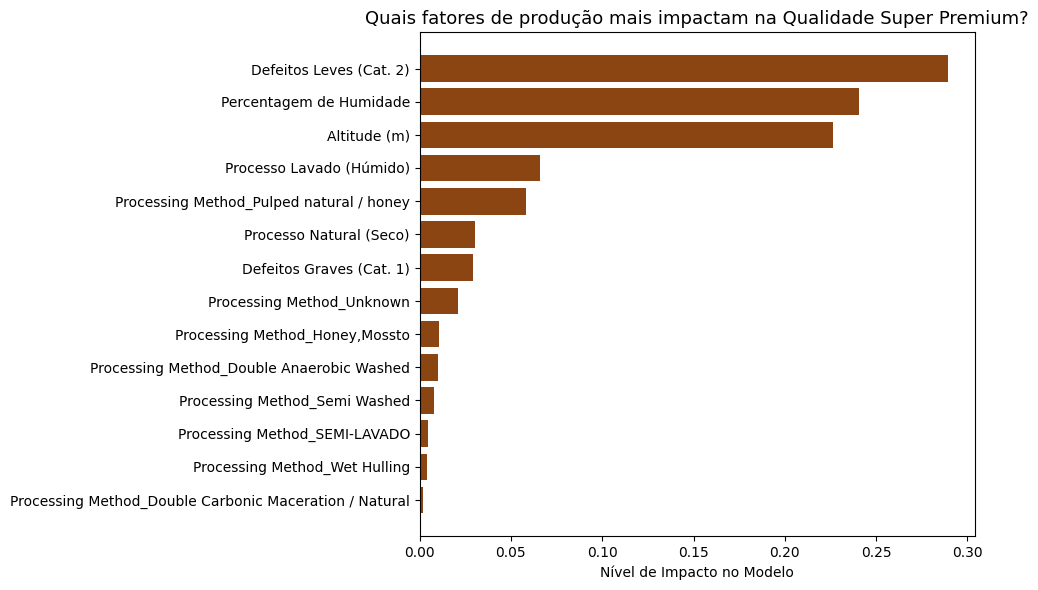

In [76]:
# Tradução das features para o gráfico final
traducao_nomes = {
    'Altitude': 'Altitude (m)',
    'Moisture Percentage': 'Percentagem de Humidade',
    'Category One Defects': 'Defeitos Graves (Cat. 1)',
    'Category Two Defects': 'Defeitos Leves (Cat. 2)',
    'Processing Method_Natural / Dry': 'Processo Natural (Seco)',
    'Processing Method_Other': 'Outros Processos',
    'Processing Method_Semi-washed / Semi-pulped': 'Processo Semi-Lavado',
    'Processing Method_Washed / Wet': 'Processo Lavado (Húmido)'
}

# Pegando a importância das variáveis do melhor modelo
melhor_rf = grid.best_estimator_
importancias = melhor_rf.feature_importances_
nomes_originais = X_train.columns

# Mapeando nomes traduzidos (se não estiver no dict, mantém o original)
nomes_final = [traducao_nomes.get(col, col) for col in nomes_originais]

# Ordenando para o gráfico
idx = np.argsort(importancias)

plt.figure(figsize=(10, 6))
plt.barh(range(len(idx)), importancias[idx], color='saddlebrown')
plt.yticks(range(len(idx)), [nomes_final[i] for i in idx])
plt.title('Quais fatores de produção mais impactam na Qualidade Super Premium?', fontsize=13)
plt.xlabel('Nível de Impacto no Modelo')
plt.tight_layout()
plt.show()

## Curiosidades e Insights de Engenharia

### A Região Importa?
Sim! Embora não tenhamos incluído a variável "Região" ou "País" no modelo para evitar um excesso de complexidade (o que chamamos de *overfitting*), os dados mostram que países como **Etiópia** e **Colômbia** têm uma concentração maior de lotes Super Premium. Isso deve-se ao "Terroir" (combinação de solo, clima e tradição produtiva).

### Por que a Altitude é tão importante?
Como vimos no gráfico de impacto, a Altitude costuma ser  um dos principais fatores. Em altitudes elevadas, o fruto do café cresce mais devagar devido às noites frias. Isso dá mais tempo para o grão concentrar açúcares e ácidos complexos, resultando numa nota de cup points mais alta.

### Conclusão do MVP
O modelo demonstrou que é possível antecipar com boa precisão se um lote será um sucesso comercial antes mesmo de ele passar pela prova final. Para a indústria, isso significa poder separar lotes de alto valor logístico e garantir que o tratamento pós-colheita seja impecável para não perder o potencial do grão.